In [2]:
#Character-Level RNN Language Model (“hello” toy & beyond)
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# -----------------------
# Load Data (toy example)
# -----------------------
text = "hello hello help hello world help hello there"
chars = sorted(list(set(text)))
vocab_size = len(chars)

char2idx = {ch:i for i,ch in enumerate(chars)}
idx2char = {i:ch for ch,i in char2idx.items()}

encoded = np.array([char2idx[c] for c in text])

# -----------------------
# Hyperparameters
# -----------------------
seq_length = 20
hidden_size = 128
batch_size = 16
epochs = 10
lr = 0.003

# -----------------------
# Create sequences
# -----------------------
def get_batch(data, seq_len, batch_size):
    ix = np.random.randint(0, len(data)-seq_len-1, batch_size)
    x = [data[i:i+seq_len] for i in ix]
    y = [data[i+1:i+seq_len+1] for i in ix]
    return torch.tensor(x), torch.tensor(y)

# -----------------------
# Model
# -----------------------
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return (torch.zeros(1, batch_size, hidden_size),
                torch.zeros(1, batch_size, hidden_size))

model = CharRNN(vocab_size, hidden_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# -----------------------
# Training Loop
# -----------------------
losses = []

for epoch in range(epochs):
    hidden = model.init_hidden(batch_size)
    x, y = get_batch(encoded, seq_length, batch_size)

    optimizer.zero_grad()
    output, hidden = model(x, hidden)

    loss = criterion(output.view(-1, vocab_size), y.view(-1))
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 2.2699
Epoch 2, Loss: 2.0513
Epoch 3, Loss: 1.8717
Epoch 4, Loss: 1.6511
Epoch 5, Loss: 1.4408
Epoch 6, Loss: 1.2943
Epoch 7, Loss: 1.1101
Epoch 8, Loss: 0.9057
Epoch 9, Loss: 0.8128
Epoch 10, Loss: 0.7480


In [3]:
#Text Generation (Sampling with Temperature)
def sample(model, start_char, length=200, temperature=1.0):
    model.eval()
    input = torch.tensor([[char2idx[start_char]]])
    hidden = model.init_hidden(1)

    result = start_char

    for _ in range(length):
        output, hidden = model(input, hidden)
        logits = output[0, -1] / temperature
        probs = torch.softmax(logits, dim=0).detach().numpy()

        char_idx = np.random.choice(len(probs), p=probs)
        char = idx2char[char_idx]

        result += char
        input = torch.tensor([[char_idx]])

    return result

print("\n--- Temperature 0.7 ---")
print(sample(model, 'h', 200, 0.7))

print("\n--- Temperature 1.0 ---")
print(sample(model, 'h', 200, 1.0))

print("\n--- Temperature 1.2 ---")
print(sample(model, 'h', 200, 1.2))


--- Temperature 0.7 ---
help help help wello hello woworll help hello helo   helo help help hello help helo elloo help help help helo hello hllo helllo hhello help hello hrlo lo oworllo helllo hello help hello hello heello he

--- Temperature 1.0 ---
heelp hello worlo hllo hllwo worldo rdlhelllo hello help help o orwpld hello hoelo hello helpr dthelo hello woelo lp hhtllhelp hellloed dwhhelp heelllo heello  helo  hellelo dhelohellr hello rlte hep h

--- Temperature 1.2 ---
hellp  help helplthllo lwwloheltwor td hp rlp hello whortlo lro h hello wrlo hweorlwodwetthllpdd helrlo dlewrphet wld heldhello eo phelo prhelllddeldhhelo hpeld hwlhlo hellprp help hello lo dwoworrllo 


Input Tokens:
 tensor([[ 8, 14, 16,  0],
        [20,  1, 18,  0],
        [ 4, 13, 11,  7],
        [ 2, 11,  9,  0],
        [ 8,  6, 13,  0],
        [16, 11, 10,  0],
        [15, 12, 17,  0],
        [ 3,  5, 13,  0],
        [19, 11, 21,  0],
        [22, 14,  0,  0]])

Contextual Embeddings:
 tensor([[[ 2.7695e-01,  4.0255e-01, -1.6351e+00,  ...,  3.8209e-01,
           2.1519e-01, -7.7184e-01],
         [-1.1326e+00,  3.7033e-02, -1.7416e+00,  ...,  7.9090e-01,
           5.9675e-02, -1.2125e+00],
         [-1.1951e-01,  9.6421e-01, -3.5885e-02,  ...,  1.5464e+00,
          -1.4393e+00,  1.3510e+00],
         [-1.5988e+00, -3.9279e-01, -6.1166e-01,  ...,  1.0737e+00,
          -1.4774e+00, -3.0645e-01]],

        [[-8.7528e-02,  3.3908e-01, -3.0615e-01,  ...,  1.0950e+00,
          -1.1441e+00, -2.1784e-02],
         [-6.8793e-01, -1.2546e+00,  1.9500e-01,  ...,  5.6495e-01,
          -5.3725e-01, -1.4815e+00],
         [ 4.9232e-01,  1.9373e+00, -1.0742e+00,  ...,  1.2121e+00,

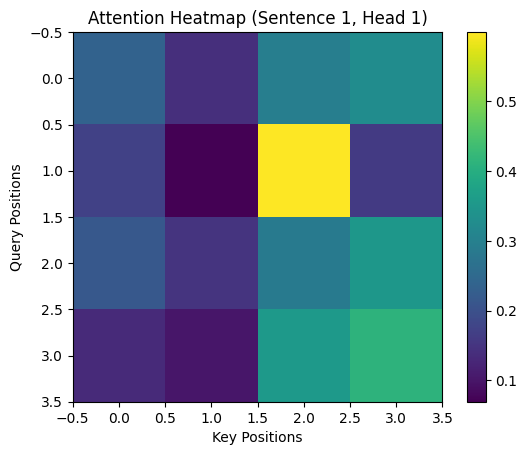

In [4]:
#Mini Transformer Encoder
# ================================
# 1. Imports
# ================================
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

# ================================
# 2. Sample Dataset
# ================================
sentences = [
    "i love nlp",
    "transformers are powerful",
    "deep learning is fun",
    "attention is important",
    "i enjoy learning",
    "nlp is interesting",
    "models learn patterns",
    "data drives learning",
    "python is useful",
    "we love ai"
]

# ================================
# 3. Tokenization
# ================================
words = " ".join(sentences).split()
vocab = sorted(list(set(words)))

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

tokenized = [[word2idx[w] for w in s.split()] for s in sentences]

# Padding
max_len = max(len(s) for s in tokenized)
padded = [s + [0]*(max_len - len(s)) for s in tokenized]

input_tensor = torch.tensor(padded)

print("Input Tokens:\n", input_tensor)

# ================================
# 4. Positional Encoding
# ================================
def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = math.sin(pos / (10000 ** ((2*i)/d_model)))
            if i+1 < d_model:
                pe[pos, i+1] = math.cos(pos / (10000 ** ((2*(i+1))/d_model)))
    return pe

# ================================
# 5. Multi-Head Attention
# ================================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        Q = Q.view(B, T, self.num_heads, self.d_k).transpose(1,2)
        K = K.view(B, T, self.num_heads, self.d_k).transpose(1,2)
        V = V.view(B, T, self.num_heads, self.d_k).transpose(1,2)

        scores = (Q @ K.transpose(-2,-1)) / math.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)

        out = attn @ V
        out = out.transpose(1,2).contiguous().view(B, T, C)

        return self.fc(out), attn

# ================================
# 6. Transformer Block
# ================================
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model*4),
            nn.ReLU(),
            nn.Linear(d_model*4, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x, attn_weights

# ================================
# 7. Full Model
# ================================
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.block = TransformerBlock(d_model, num_heads)

    def forward(self, x):
        seq_len = x.size(1)
        x = self.embedding(x)

        pe = positional_encoding(seq_len, x.size(2))
        x = x + pe

        out, attn = self.block(x)
        return out, attn

# ================================
# 8. Run Model
# ================================
model = MiniTransformer(len(vocab))

output, attention = model(input_tensor)

# ================================
# 9. Print Outputs
# ================================
print("\nContextual Embeddings:\n", output)

print("\nAttention Weights (Sentence 1, Head 1):\n")
print(attention[0][0])

# ================================
# 10. Heatmap Visualization
# ================================
plt.figure()
plt.imshow(attention[0][0].detach().numpy())
plt.colorbar()
plt.title("Attention Heatmap (Sentence 1, Head 1)")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.show()

In [5]:
#Implement Scaled Dot-Product Attention
import torch
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V):
    """
    Computes Scaled Dot-Product Attention.
    """
    # 1. Calculate Dot Product of Q and K^T
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # Stability Check: Before Scaling
    print(f"--- Stability Check ---")
    print(f"Max score (pre-scaling): {scores.max().item():.4f}")

    # 2. Scale by sqrt(d_k)
    scaled_scores = scores / (d_k ** 0.5)
    print(f"Max score (post-scaling): {scaled_scores.max().item():.4f}\n")

    # 3. Apply Softmax to get Attention Weights
    attention_weights = F.softmax(scaled_scores, dim=-1)

    # 4. Multiply weights by V
    output = torch.matmul(attention_weights, V)

    return output, attention_weights

# --- Testing with Random Inputs ---
# Dimensions: [Batch Size, Num_Heads, Seq_Length, Depth]
# Let's keep it simple: [1, 1, 3, 4] -> 3 words, each embedding size 4
torch.manual_seed(42)
Q = torch.randn(1, 1, 3, 4)
K = torch.randn(1, 1, 3, 4)
V = torch.randn(1, 1, 3, 4)

output, weights = scaled_dot_product_attention(Q, K, V)

print("--- Results ---")
print("1. Attention Weight Matrix:")
print(weights)

print("\n2. Output Vectors:")
print(output)

--- Stability Check ---
Max score (pre-scaling): 1.2760
Max score (post-scaling): 0.6380

--- Results ---
1. Attention Weight Matrix:
tensor([[[[0.3017, 0.3098, 0.3884],
          [0.2451, 0.3801, 0.3748],
          [0.2938, 0.2293, 0.4769]]]])

2. Output Vectors:
tensor([[[[ 0.1212,  0.5156, -0.2394, -0.1912],
          [ 0.0999,  0.5376, -0.2558, -0.1143],
          [ 0.1348,  0.5492, -0.3327, -0.3267]]]])
